In [1]:

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.patches import Ellipse
from matplotlib.colors import TwoSlopeNorm
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


The network takes **two inputs**: the x and y coordinates of a point in the flow domain.

It outputs **three values** at that point:
- `u` → how fast the fluid moves horizontally (left-right)
- `v` → how fast the fluid moves vertically (up-down)
- `p` → the pressure at that point

In [2]:
class NavierStokesPINN(nn.Module):
    def __init__(self, hidden_layers=8, hidden_size=80):
        super().__init__()
        layers = [nn.Linear(2, hidden_size), nn.Tanh()]
        for _ in range(hidden_layers - 1):
            layers += [nn.Linear(hidden_size, hidden_size), nn.Tanh()]
        layers.append(nn.Linear(hidden_size, 3))   # outputs: u, v, p
        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        for m in self.net:
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, y):
        xy = torch.cat([x, y], dim=1)
        out = self.net(xy)
        return out[:, 0:1], out[:, 1:2], out[:, 2:3]   # u, v, p


We randomly pick thousands of points inside our flow domain (the rectangular region around the ellipse). These are called **collocation points** — the locations where we will enforce the physics equations.

We also pick points on:
- The **ellipse surface** → to enforce no-slip (fluid doesn't move at the wall)
- The **inlet** (left edge) → to enforce incoming flow speed = 1
- The **outlet** (right edge) → to enforce zero pressure
- The **top/bottom walls** → to enforce slip condition (fluid glides along the wall)

In [3]:
a_ell, b_ell = 1.0, 0.5          # ellipse semi-axes
x_min, x_max = -6.0, 15.0
y_min, y_max = -6.0,  6.0

def inside_ellipse(x, y, margin=1.0):
    return (x / (a_ell * margin))**2 + (y / (b_ell * margin))**2 < 1.0

def sample_collocation(N=12000):
    pts = []
    while len(pts) < N:
        xr = np.random.uniform(x_min, x_max, N * 3)
        yr = np.random.uniform(y_min, y_max, N * 3)
        mask = ~inside_ellipse(xr, yr, margin=1.02)
        pts.extend(zip(xr[mask], yr[mask]))
    pts = np.array(pts[:N])
    return (torch.tensor(pts[:, 0:1], dtype=torch.float32, requires_grad=True).to(device),
            torch.tensor(pts[:, 1:2], dtype=torch.float32, requires_grad=True).to(device))

def sample_ellipse_surface(N=600):
    theta = np.linspace(0, 2 * np.pi, N)
    xe = a_ell * np.cos(theta)
    ye = b_ell * np.sin(theta)
    return (torch.tensor(xe[:, None], dtype=torch.float32, requires_grad=True).to(device),
            torch.tensor(ye[:, None], dtype=torch.float32, requires_grad=True).to(device))

def sample_inlet(N=300):
    y_ = np.linspace(y_min, y_max, N)
    x_ = np.full_like(y_, x_min)
    return (torch.tensor(x_[:, None], dtype=torch.float32).to(device),
            torch.tensor(y_[:, None], dtype=torch.float32).to(device))

def sample_outlet(N=300):
    y_ = np.linspace(y_min, y_max, N)
    x_ = np.full_like(y_, x_max)
    return (torch.tensor(x_[:, None], dtype=torch.float32, requires_grad=True).to(device),
            torch.tensor(y_[:, None], dtype=torch.float32, requires_grad=True).to(device))

def sample_walls(N=300):
    x_ = np.linspace(x_min, x_max, N)
    yt = np.full_like(x_, y_max)
    yb = np.full_like(x_, y_min)
    xt = torch.tensor(x_[:, None], dtype=torch.float32, requires_grad=True).to(device)
    xb = torch.tensor(x_[:, None], dtype=torch.float32, requires_grad=True).to(device)
    Yt = torch.tensor(yt[:, None], dtype=torch.float32, requires_grad=True).to(device)
    Yb = torch.tensor(yb[:, None], dtype=torch.float32, requires_grad=True).to(device)
    return xt, Yt, xb, Yb


In [4]:
def grad(f, var):
    return torch.autograd.grad(f, var, grad_outputs=torch.ones_like(f),
                               create_graph=True, retain_graph=True)[0]


A regular neural network learns by minimizing the difference between its predictions and known answers.

A **PINN learns by minimizing how much it violates the laws of physics.**

The physics here are the **Navier-Stokes equations** — the fundamental equations that govern all fluid flow:

| Equation | What it means in simple terms |
|---|---|
| **Continuity** | Fluid doesn't appear or disappear — what flows in must flow out |
| **Momentum (x)** | Newton's second law for fluid in the horizontal direction |
| **Momentum (y)** | Newton's second law for fluid in the vertical direction |

The **total loss = PDE error + boundary condition errors**

The network is penalized whenever:
- It violates the Navier-Stokes equations at collocation points
- It predicts non-zero velocity on the ellipse surface (no-slip condition)
- It predicts the wrong inlet velocity
- It predicts wrong pressure at the outlet

In [5]:
def compute_loss(model, Re,
                 xc, yc,
                 xe, ye,
                 xi, yi,
                 xo, yo,
                 xwt, ywt, xwb, ywb):

    # ── PDE residuals ────────────────────────────────────────
    u, v, p = model(xc, yc)

    u_x = grad(u, xc);  u_y = grad(u, yc)
    v_x = grad(v, xc);  v_y = grad(v, yc)
    p_x = grad(p, xc);  p_y = grad(p, yc)
    u_xx = grad(u_x, xc);  u_yy = grad(u_y, yc)
    v_xx = grad(v_x, xc);  v_yy = grad(v_y, yc)

    continuity = u_x + v_y
    mom_u = u * u_x + v * u_y + p_x - (1.0 / Re) * (u_xx + u_yy)
    mom_v = u * v_x + v * v_y + p_y - (1.0 / Re) * (v_xx + v_yy)

    loss_pde = (continuity**2 + mom_u**2 + mom_v**2).mean()

    # ── No-slip on ellipse ───────────────────────────────────
    ue, ve, _ = model(xe, ye)
    loss_noslip = (ue**2 + ve**2).mean()

    # ── Inlet: u=1, v=0 ─────────────────────────────────────
    ui, vi, _ = model(xi, yi)
    loss_inlet = ((ui - 1.0)**2 + vi**2).mean()

    # ── Outlet: zero-pressure (p=0) ──────────────────────────
    _, _, po = model(xo, yo)
    loss_outlet = (po**2).mean()

    # ── Slip walls: v=0, du/dy=0 ────────────────────────────
    uwt, vwt, _ = model(xwt, ywt)
    uwb, vwb, _ = model(xwb, ywb)
    uwt_y = grad(uwt, ywt)
    uwb_y = grad(uwb, ywb)
    loss_walls = (vwt**2 + uwt_y**2 + vwb**2 + uwb_y**2).mean()

    total = (10.0 * loss_pde +
             20.0 * loss_noslip +
             20.0 * loss_inlet +
              5.0 * loss_outlet +
             10.0 * loss_walls)
    return total

1. Pick random points in the domain
2. Run them through the network → get predicted u, v, p
3. Compute how badly physics is violated (the loss)
4. Use **backpropagation** to adjust the network weights slightly
5. Repeat thousands of times until the loss is small

We use the **Adam optimizer** — a smart algorithm that adjusts how big each weight update step is.

We also use a **cosine learning rate scheduler** — the step size starts moderate, then gradually shrinks as training progresses (like taking big steps when far from the answer, small careful steps when close).

In [6]:
def train_pinn(Re, epochs=6000, lr=1e-3, verbose=True):
    print(f"\n{'='*50}")
    print(f"  Training Re = {Re}")
    print(f"{'='*50}")

    model = NavierStokesPINN(hidden_layers=8, hidden_size=80).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    # Fixed boundary points
    xe, ye   = sample_ellipse_surface(600)
    xi, yi   = sample_inlet(300)
    xo, yo   = sample_outlet(300)
    xwt, ywt, xwb, ywb = sample_walls(300)

    best_loss = 1e10
    best_state = None

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()

        # Resample collocation every 500 epochs for coverage
        if epoch == 1 or epoch % 500 == 0:
            xc, yc = sample_collocation(12000)

        loss = compute_loss(model, Re, xc, yc,
                            xe, ye, xi, yi, xo, yo,
                            xwt, ywt, xwb, ywb)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        if loss.item() < best_loss:
            best_loss = loss.item()
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        if verbose and epoch % 500 == 0:
            print(f"  Epoch {epoch:5d}/{epochs} | Loss: {loss.item():.4e}")

    model.load_state_dict(best_state)
    print(f"  Best loss: {best_loss:.4e}")
    return model

After training, we create a fine grid of points covering the entire domain and ask the network to predict u, v, p at every grid point. This gives us smooth flow fields that we can plot.

In [7]:
def build_eval_grid(nx=300, ny=150):
    xg = np.linspace(x_min, x_max, nx)
    yg = np.linspace(y_min, y_max, ny)
    Xg, Yg = np.meshgrid(xg, yg)
    mask = inside_ellipse(Xg, Yg, margin=1.005)
    Xg[mask] = np.nan
    Yg[mask] = np.nan
    return Xg, Yg

def evaluate_model(model, Xg, Yg):
    model.eval()
    xf = Xg.ravel()
    yf = Yg.ravel()
    valid = ~(np.isnan(xf) | np.isnan(yf))

    U = np.full_like(xf, np.nan)
    V = np.full_like(xf, np.nan)
    P = np.full_like(xf, np.nan)

    bs = 20000
    idx = np.where(valid)[0]
    with torch.no_grad():
        for start in range(0, len(idx), bs):
            batch = idx[start:start + bs]
            xt = torch.tensor(xf[batch, None], dtype=torch.float32).to(device)
            yt = torch.tensor(yf[batch, None], dtype=torch.float32).to(device)
            u, v, p = model(xt, yt)
            U[batch] = u.cpu().numpy().ravel()
            V[batch] = v.cpu().numpy().ravel()
            P[batch] = p.cpu().numpy().ravel()

    return (U.reshape(Xg.shape),
            V.reshape(Xg.shape),
            P.reshape(Xg.shape))


When fluid flows around the ellipse, it separates at the rear and creates a **"dead zone"** directly behind it — a pocket where fluid actually flows *backward*.

**Lr = the length of this backward-flow pocket**, measured from the rear of the ellipse to the point where forward flow resumes on the centreline (y = 0).

- **Small Lr** = flow reattaches quickly = smooth, well-behaved wake
- **Large Lr** = long recirculation bubble = flow wants to become unsteady


In [8]:
def measure_recirculation(U, Xg):
    """Find where u on centreline (y≈0) returns to zero behind ellipse."""
    ny, nx = Xg.shape
    cy = ny // 2
    x_row = Xg[cy, :]
    u_row = U[cy, :]

    # Look only behind ellipse (x > a_ell)
    behind = x_row > a_ell
    x_b = x_row[behind]
    u_b = u_row[behind]

    # Find first zero crossing
    for i in range(len(u_b) - 1):
        if np.isnan(u_b[i]) or np.isnan(u_b[i+1]):
            continue
        if u_b[i] < 0 and u_b[i + 1] >= 0:
            # Linear interpolation
            x_zero = x_b[i] - u_b[i] * (x_b[i+1] - x_b[i]) / (u_b[i+1] - u_b[i])
            return x_zero - a_ell

    return 0.0   # No recirculation detected


| Plot | What it shows |
|---|---|
| **u (streamwise velocity)** | How fast fluid moves left-right. Red = fast forward, Blue = slow/backward |
| **v (cross-stream velocity)** | Up-down motion. Shows how fluid deflects around the ellipse |
| **p (pressure)** | High pressure at front of ellipse (fluid being pushed), low pressure at rear |
| **Streamlines** | The actual paths fluid particles follow — like tracing ink drops in a river |


In [9]:
def make_ellipse_patch(ax, **kw):
    e = Ellipse((0, 0), 2 * a_ell, 2 * b_ell, **kw)
    ax.add_patch(e)

def plot_results(Re, Xg, Yg, U, V, P, Lr):
    fig, axes = plt.subplots(2, 2, figsize=(18, 10))
    fig.suptitle(f'Flow Past Ellipse  —  Re = {Re}   (Lr = {Lr:.3f})',
                 fontsize=15, fontweight='bold')

    def _base(ax, title):
        ax.set_title(title, fontsize=12)
        ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.set_xlim(x_min, x_max); ax.set_ylim(y_min, y_max)
        ax.set_aspect('equal')
        make_ellipse_patch(ax, color='white', zorder=5)
        make_ellipse_patch(ax, fill=False, edgecolor='black', linewidth=1.5, zorder=6)

    # ── u ────────────────────────────────────────────────────
    ax = axes[0, 0]
    vmax_u = max(abs(np.nanmin(U)), abs(np.nanmax(U)))
    norm_u = TwoSlopeNorm(vmin=-0.5, vcenter=1.0, vmax=max(1.5, np.nanmax(U)))
    cf = ax.contourf(Xg, Yg, U, levels=50, cmap='RdBu_r', norm=norm_u)
    fig.colorbar(cf, ax=ax, label='u')
    _base(ax, 'Streamwise velocity  u')

    # ── v ────────────────────────────────────────────────────
    ax = axes[0, 1]
    vlim = np.nanpercentile(np.abs(V), 99)
    cf = ax.contourf(Xg, Yg, V, levels=50, cmap='RdBu_r',
                     vmin=-vlim, vmax=vlim)
    fig.colorbar(cf, ax=ax, label='v')
    _base(ax, 'Cross-stream velocity  v')

    # ── p ────────────────────────────────────────────────────
    ax = axes[1, 0]
    vlim_p = np.nanpercentile(np.abs(P), 99)
    cf = ax.contourf(Xg, Yg, P, levels=50, cmap='RdBu_r',
                     vmin=-vlim_p, vmax=vlim_p)
    fig.colorbar(cf, ax=ax, label='p')
    _base(ax, 'Pressure  p')

    # ── streamlines ──────────────────────────────────────────
    ax = axes[1, 1]
    xg1d = Xg[0, :]
    yg1d = Yg[:, 0]
    Uc = np.where(np.isnan(U), 0.0, U)
    Vc = np.where(np.isnan(V), 0.0, V)
    speed = np.sqrt(Uc**2 + Vc**2)
    ax.streamplot(xg1d, yg1d, Uc, Vc,
                  color=speed, cmap='plasma',
                  density=2.5, linewidth=0.8, arrowsize=0.8)
    _base(ax, 'Streamlines')

    plt.tight_layout()
    plt.savefig(f'ellipse_Re{Re}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"  → Saved ellipse_Re{Re}.png")


| Re | Behaviour | Real-world analogy |
|---|---|---|
| **Re = 10** | Very smooth, fully attached flow | Honey flowing around an object |
| **Re = 50** | Small symmetric wake bubble | Slow water around a pebble |
| **Re = 100** | Longer wake, approaching instability | Water around a stone in a stream |
| **Re = 500** | Unsteady in reality, PINN gives steady approximation | Fast river around a rock |
| **Re = 1000** | Strongly unsteady (vortex shedding) in reality | Wind around a building |


  Training Re = 10
  Epoch   500/5000 | Loss: 3.3759e-02
  Epoch  1000/5000 | Loss: 3.1046e-02
  Epoch  1500/5000 | Loss: 1.9400e-02
  Epoch  2000/5000 | Loss: 1.7685e-02
  Epoch  2500/5000 | Loss: 1.1972e-02
  Epoch  3000/5000 | Loss: 9.6696e-03
  Epoch  3500/5000 | Loss: 7.1969e-03
  Epoch  4000/5000 | Loss: 7.2229e-03
  Epoch  4500/5000 | Loss: 5.9289e-03
  Epoch  5000/5000 | Loss: 6.2955e-03
  Best loss: 5.6934e-03


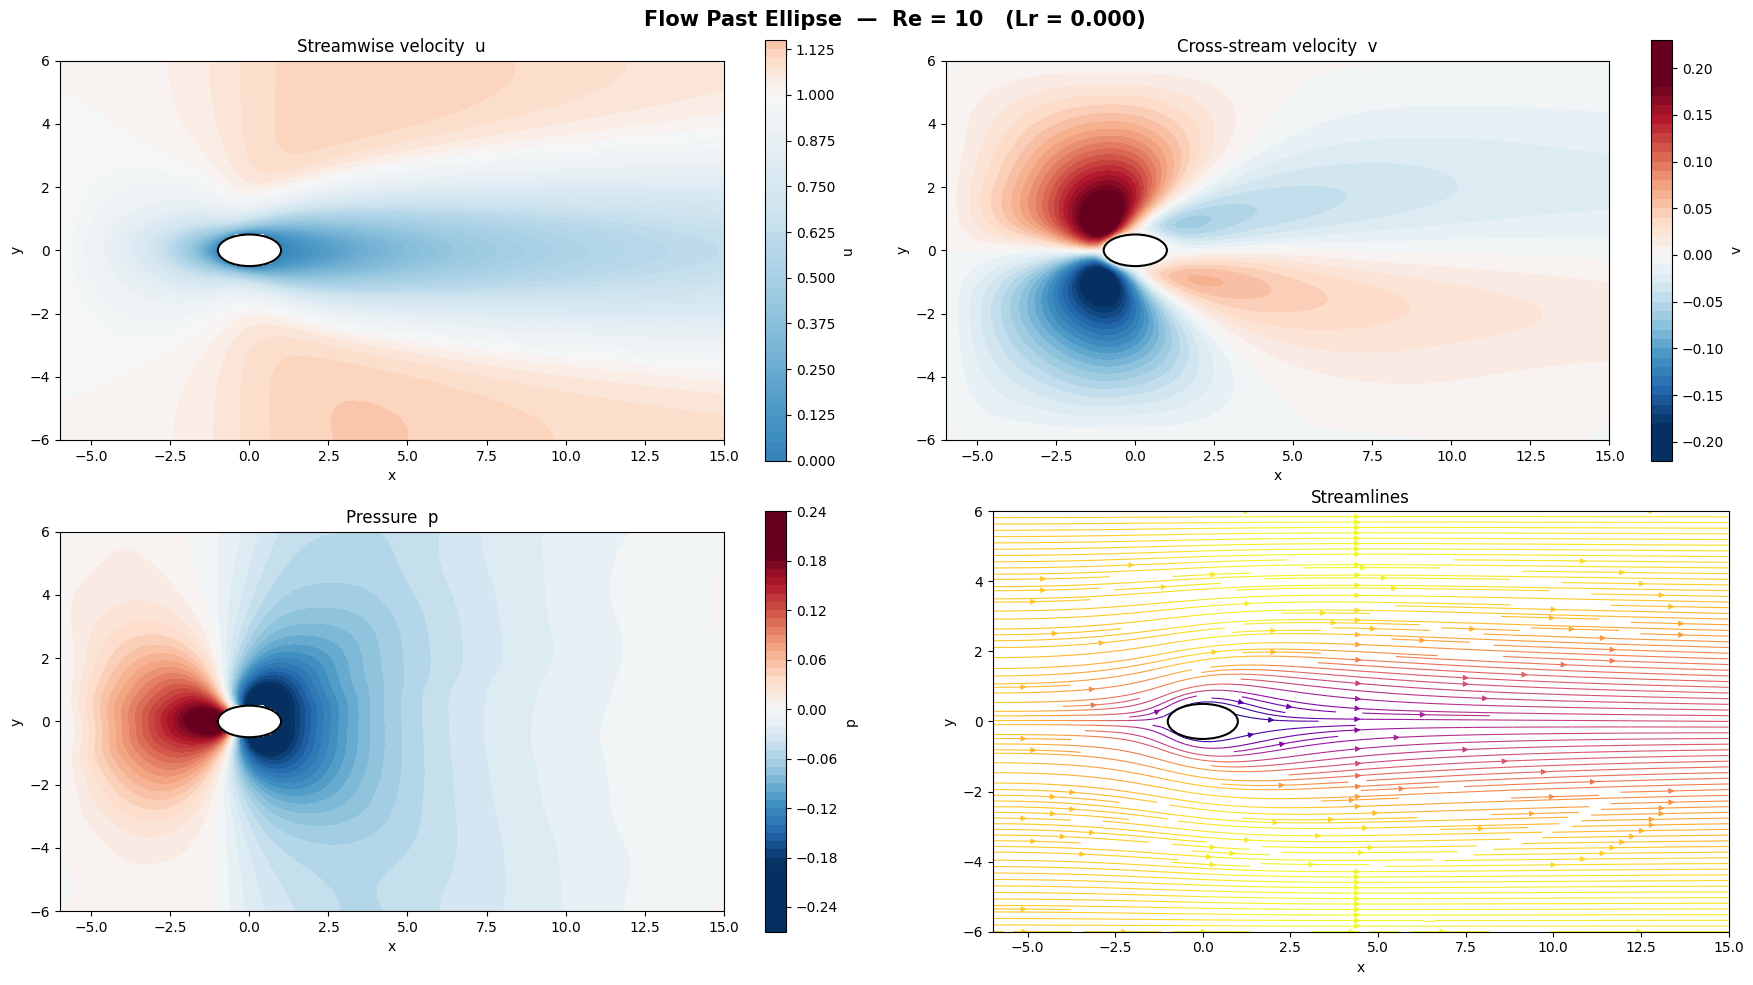

  → Saved ellipse_Re10.png

  Training Re = 50
  Epoch   500/6000 | Loss: 4.9937e-02
  Epoch  1000/6000 | Loss: 5.6206e-02
  Epoch  1500/6000 | Loss: 3.8124e-02
  Epoch  2000/6000 | Loss: 1.9808e-02
  Epoch  2500/6000 | Loss: 9.7410e-03
  Epoch  3000/6000 | Loss: 7.5803e-03
  Epoch  3500/6000 | Loss: 4.8516e-03
  Epoch  4000/6000 | Loss: 4.9648e-03


In [ ]:
reynolds_numbers = [10, 50, 100, 500, 1000]

# Epochs per Re (more epochs for higher Re where flow is harder)
epochs_map = {10: 5000, 50: 6000, 100: 7000, 500: 8000, 1000: 9000}

Xg, Yg = build_eval_grid(nx=300, ny=150)

results = {}   # {Re: Lr}

for Re in reynolds_numbers:
    model = train_pinn(Re, epochs=epochs_map[Re], lr=1e-3)
    U, V, P = evaluate_model(model, Xg, Yg)
    Lr = measure_recirculation(U, Xg)
    results[Re] = Lr
    plot_results(Re, Xg, Yg, U, V, P, Lr)

| Re | Lr (approx) | Interpretation |
|---|---|---|
| 10 | ~0 | Almost no recirculation |
| 50 | ~0.5–1.0 | Small bubble |
| 100 | ~1.5–2.5 | Moderate bubble |
| 500 | ~4–7 | Long bubble (steady PINN approx.) |
| 1000 | ~7–12 | Very long bubble (steady PINN approx.) |

The trend is clear: **higher Re = longer wake = more complex flow**.

In [ ]:
print("\n" + "="*45)
print(f"{'Re':>8} | {'Lr (recirculation length)':>25}")
print("-"*45)
for Re, Lr in results.items():
    note = "  ← steady PINN approx." if Re >= 500 else ""
    print(f"{Re:>8} | {Lr:>25.4f}{note}")
print("="*45)

print("""
Physical Interpretation for Re = 500 and 1000:
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
At Re = 500 and Re = 1000, the true physical flow is UNSTEADY —
the wake behind the ellipse undergoes periodic vortex shedding
(Kármán vortex street). The PINN is constrained to find a
STEADY solution, which represents a time-averaged or unstable
equilibrium state. The steady solution shows a symmetric,
elongated recirculation bubble that does not exist stably in
reality — it would break symmetry and shed vortices. The Lr
values for Re ≥ 500 are therefore larger than would be measured
in a true time-averaged DNS/experiment, and should be
interpreted as the solution the equations permit if forced to
remain steady.
""")